In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import re
from matplotlib.ticker import ScalarFormatter
# set the graphs to show in the jupyter notebook
%matplotlib inline

In [2]:
pc = pd.read_csv('C://Users//Lenovo//Desktop//Python//vis cs4//SalesData.csv')
pc.head()

,AccountId,AccountName,Region,Division,City,State,Tier,Month,Sales2015,Sales2016,Units2015,Units2016,TargetAchevied2015,TargetAchevied2016
0,1116,Account1,West,DIAMONDBACK,PHOENIX W,AZ,Low,Aug,0.00,13208.52,0.0,4.0,0.70,1.53
1,1116,Account1,West,DIAMONDBACK,PHOENIX W,AZ,Low,Oct,10500.78,23114.91,3.0,7.0,0.84,1.31
2,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Jun,0.00,6627.00,0.0,3.0,1.15,1.29
3,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Mar,19881.00,13254.00,9.0,6.0,1.33,1.17
4,2397,Account3,East,MINUTEMEN,WORCESTER,MA,Med,Sep,3684.48,0.00,1.0,0.0,1.02,1.53


In [3]:
pc.columns

Index(['AccountId', 'AccountName', 'Region', 'Division', 'City', 'State',
       'Tier', 'Month', 'Sales2015', 'Sales2016', 'Units2015', 'Units2016',
       'TargetAchevied2015', 'TargetAchevied2016'],
      dtype='object')

In [4]:
pc.dtypes

AccountId               int64
AccountName            object
Region                 object
Division               object
City                   object
State                  object
Tier                   object
Month                  object
Sales2015             float64
Sales2016             float64
Units2015             float64
Units2016             float64
TargetAchevied2015    float64
TargetAchevied2016    float64
dtype: object

### 1. Compare Sales by region for 2016 with 2015 using bar chart

In [5]:
sales_by_region = pc.groupby('Region')[['Sales2015', 'Sales2016']].sum()
sales_by_region = sales_by_region.astype(int)
sales_by_region

,Sales2015,Sales2016
Region,,
Central,7891728,9787808
East,9512916,12667230
West,5349744,7209689


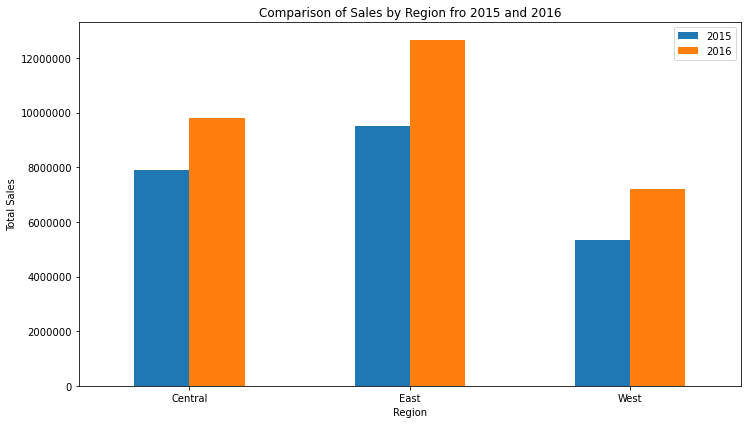

In [37]:
sales_by_region.plot(kind='bar' , figsize=(10,6))
plt.title('Comparison of Sales by Region fro 2015 and 2016')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation = 0)
plt.legend(['2015', '2016'])
plt.tight_layout()
plt.gca().get_yaxis().get_major_formatter().set_scientific(False)
plt.show()

### 2. What are the contributing factors to the sales for each region in 2016. Visualize it using a Pie Chart.


In [7]:
sales_by_region_2016 = pc.groupby('Region')[['Sales2016']].sum()
sales_by_region_2016.astype(int)

,Sales2016
Region,
Central,9787808
East,12667230
West,7209689


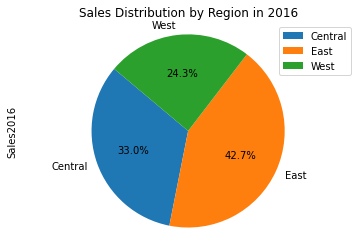

In [8]:
sales_by_region_2016.plot.pie(autopct='%1.1f%%', startangle=140, subplots=True)
plt.title('Sales Distribution by Region in 2016')
plt.axis('equal')  
plt.show()

### 3. Compare the total sales of 2015 and 2016 with respect to Region and Tiers

In [12]:
rt = pc.groupby(['Region','Tier'])[['Sales2015', 'Sales2016']].sum()
rt = rt.astype(int)
rt

Sales2015  Sales2016
Region  Tier                      
Central High    4798698    6026042
        Low      943439    1132832
        Med     2068225    2632181
        Out       81364      -3248
East    High    6102946    7817151
        Low      901665    1144929
        Med     2470998    3705149
        Out       37306          0
West    High    2944789    3768038
        Low      671064    1099502
        Med     1718475    2342148
        Out       15415          0

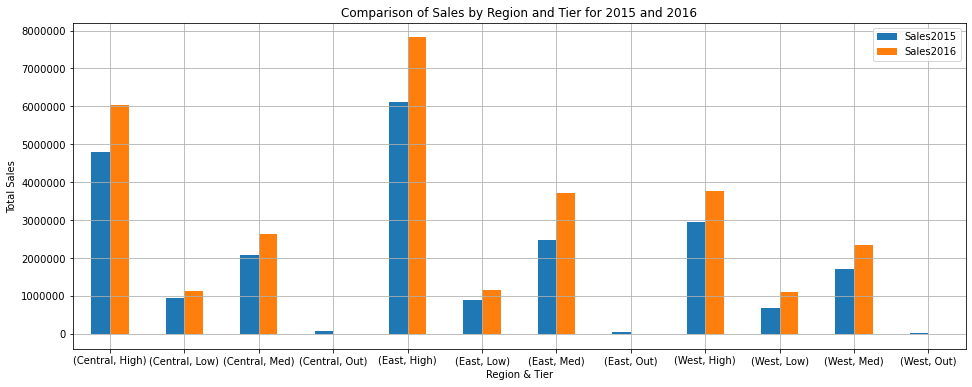

In [36]:
rt.plot(kind='bar', figsize=(16, 6))
plt.title('Comparison of Sales by Region and Tier for 2015 and 2016')
plt.xlabel('Region & Tier')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(rotation=0)
plt.gca().get_yaxis().get_major_formatter().set_scientific(False)
plt.show()

### 4. In East region, which state registered a decline in 2016 as compared to 2015?

In [32]:
eastr = pc[pc['Region'] == 'East']
eastr.head()

,AccountId,AccountName,Region,Division,City,State,Tier,Month,Sales2015,Sales2016,Units2015,Units2016,TargetAchevied2015,TargetAchevied2016
2,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Jun,0.00,6627.00,0.0,3.0,1.15,1.29
3,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Mar,19881.00,13254.00,9.0,6.0,1.33,1.17
4,2397,Account3,East,MINUTEMEN,WORCESTER,MA,Med,Sep,3684.48,0.00,1.0,0.0,1.02,1.53
5,2400,Account4,East,MINUTEMEN,PORTLAND,ME,High,Jul,0.00,10525.24,0.0,4.0,1.03,1.45
6,2400,Account4,East,MINUTEMEN,PORTLAND,ME,High,Feb,2631.31,42812.62,1.0,17.0,1.08,0.99


In [33]:
east_data = eastr.groupby('State')[['Sales2015', 'Sales2016']].sum()
east_data = east_data.astype(int)
east_data

,Sales2015,Sales2016
State,,
CT,197202,323502
DC,216723,257421
FL,1660162,2508232
GA,681546,946919
MA,419278,687096
MD,527309,750008
ME,77425,183673
NC,1292801,1610521
NH,136419,144717


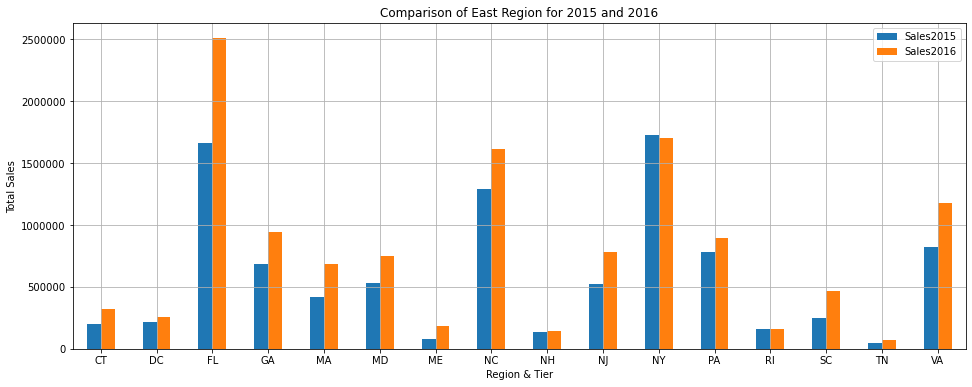

In [45]:
ax = east_data.plot(kind='bar', figsize=(16, 6))
plt.title('Comparison of East Region for 2015 and 2016')
plt.xlabel('Region & Tier')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(rotation=0)
plt.gca().get_yaxis().get_major_formatter().set_scientific(False)
plt.show()

### 5. In all the High tier, which Division saw a decline in number of units sold in 2016 compared to 2015?


In [44]:
ht = pc[pc['Tier'] == 'High']
ht_data = ht.groupby('Division')[['Units2015','Units2016']].sum()
ht_data

,Units2015,Units2016
Division,,
BIG APPLE,180.8330,231.0000
CHARGERS,123.6666,164.4999
CONGRESSIONAL,164.5003,205.0000
DIAMONDBACK,153.3334,176.6667
EMPIRE,414.3332,449.3332
GRIDIRON,213.6673,246.1675
GULF STREAM,185.0000,301.0009
HAILSTORM,187.8338,247.0003
KINETIC,214.3334,244.5001


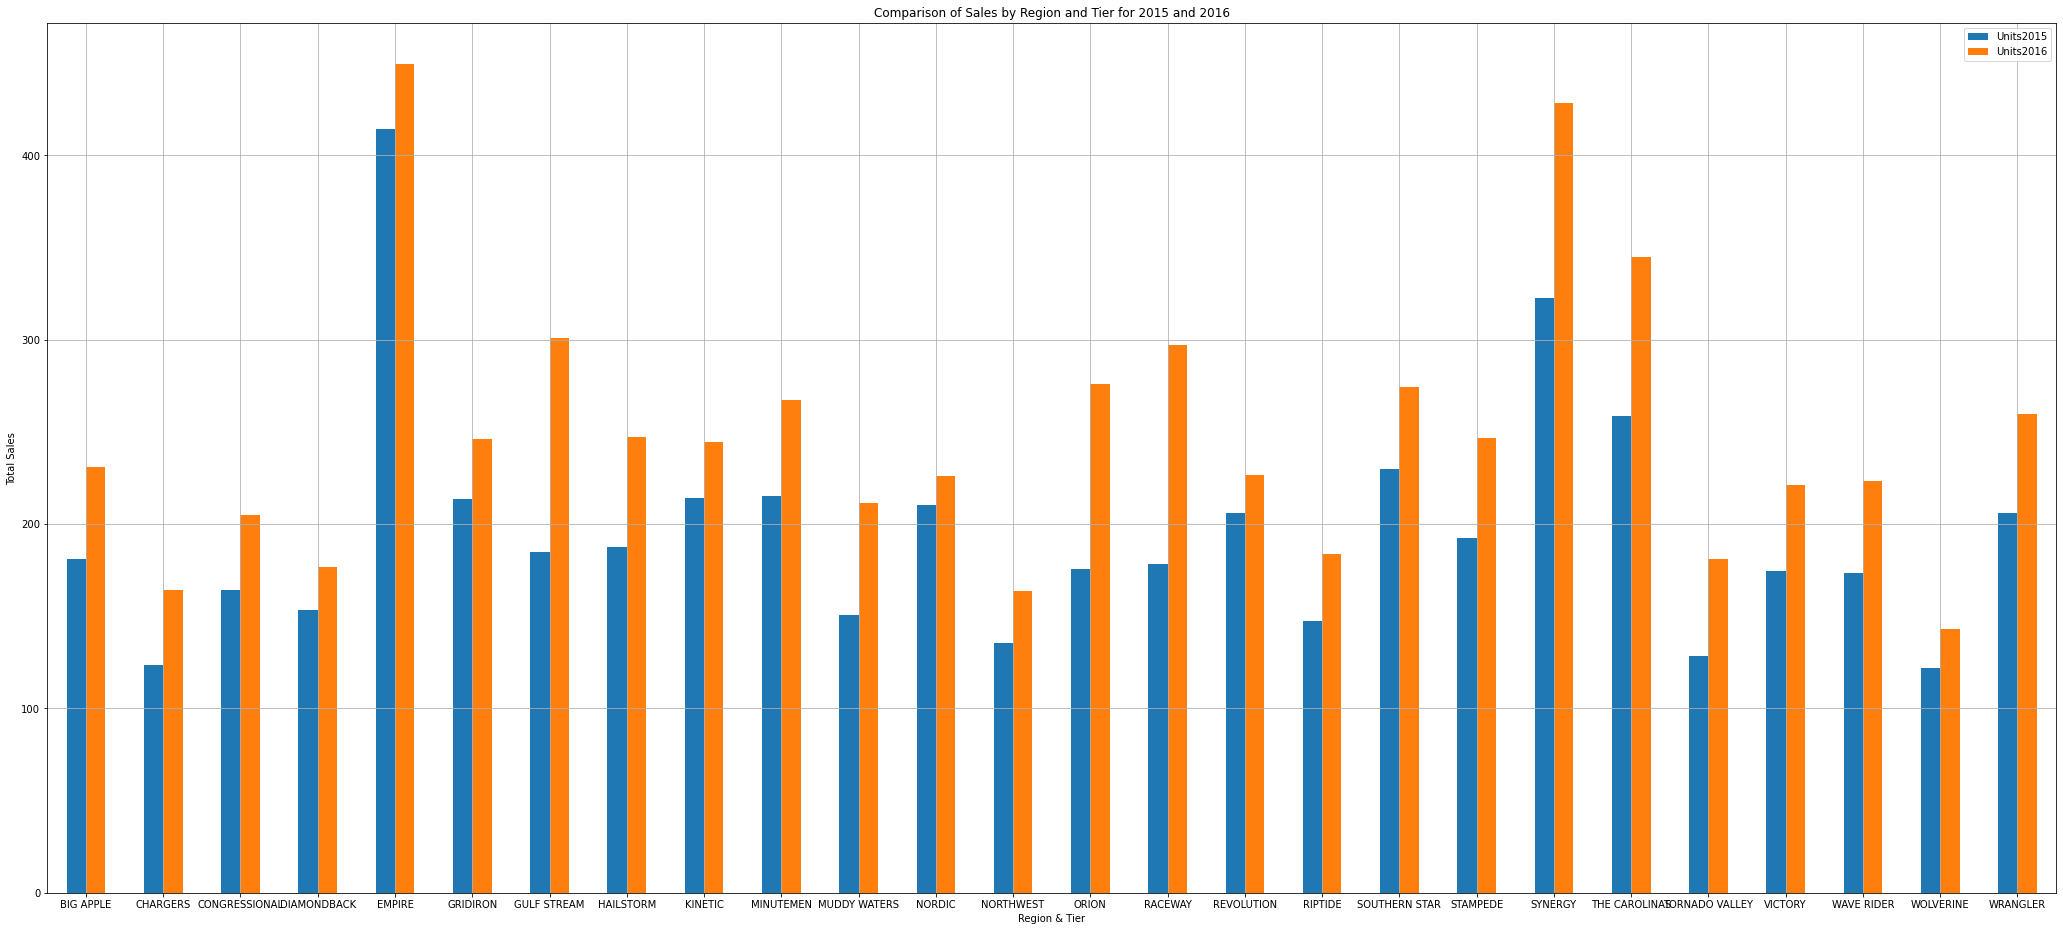

In [54]:
ht_data.plot(kind='bar', figsize=(36, 16))
plt.title('Comparison of Sales by Region and Tier for 2015 and 2016')
plt.xlabel('Region & Tier')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(rotation=0)
plt.gca().get_yaxis().get_major_formatter().set_scientific(False)
plt.show()

### 6. Create a new column Qtr using numpy.where() or any suitable utility in the imported dataset. The Quarters are based on months and defined as -
• Jan - Mar : Q1
• Apr - Jun : Q2
• Jul - Sep : Q3
• Oct - Dec : Q4

In [57]:
conditions = [
    (pc['Month'].str.contains('Jan|Feb|Mar')),
    (pc['Month'].str.contains('Apr|May|Jun')),
    (pc['Month'].str.contains('Jul|Aug|Sep')),
    (pc['Month'].str.contains('Oct|Nov|Dec')),
]

Quarters = ['Q1','Q2','Q3','Q4']
pc['Quarter'] = np.select(conditions, Quarters)
pc.head()

,AccountId,AccountName,Region,Division,City,State,Tier,Month,Sales2015,Sales2016,Units2015,Units2016,TargetAchevied2015,TargetAchevied2016,Quarter
0,1116,Account1,West,DIAMONDBACK,PHOENIX W,AZ,Low,Aug,0.00,13208.52,0.0,4.0,0.70,1.53,Q3
1,1116,Account1,West,DIAMONDBACK,PHOENIX W,AZ,Low,Oct,10500.78,23114.91,3.0,7.0,0.84,1.31,Q4
2,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Jun,0.00,6627.00,0.0,3.0,1.15,1.29,Q2
3,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Mar,19881.00,13254.00,9.0,6.0,1.33,1.17,Q1
4,2397,Account3,East,MINUTEMEN,WORCESTER,MA,Med,Sep,3684.48,0.00,1.0,0.0,1.02,1.53,Q3


### 7. Compare Qtr wise sales in 2015 and 2016 in a bar plot

In [64]:
qtr = pc.groupby('Quarter')[['Sales2015','Sales2016']].sum()
qtr = qtr.astype(int)
qtr

,Sales2015,Sales2016
Quarter,,
Q1,5485800,6997953
Q2,5390862,7237361
Q3,6164093,7861546
Q4,5713633,7567868


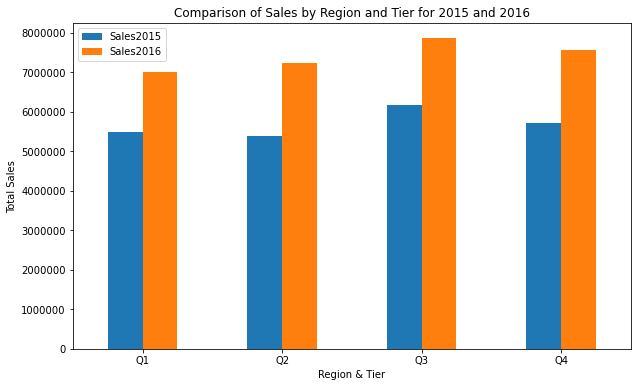

In [72]:
qtr.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of Sales by Region and Tier for 2015 and 2016')
plt.xlabel('Region & Tier')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.gca().get_yaxis().get_major_formatter().set_scientific(False)
plt.show()

### 8. Determine the composition of Qtr wise sales in and 2016 with regards to all the Tiers in a pie chart.
 (Draw 4 pie charts representing a Quarter for each Tier)

In [88]:
q1 = pc[(pc['Quarter'] == 'Q1')]
q2 = pc[(pc['Quarter'] == 'Q2')]
q3 = pc[(pc['Quarter'] == 'Q3')]
q4 = pc[(pc['Quarter'] == 'Q4')]

q1_data = q1.groupby('Tier')[['Sales2016']].sum()
q2_data = q2.groupby('Tier')['Sales2016'].sum()
q3_data = q3.groupby('Tier')['Sales2016'].sum()
q4_data = q4.groupby('Tier')['Sales2016'].sum()

q1_data = q1_data.astype(int)
q1_data

,Sales2016
Tier,
High,3867718
Low,948832
Med,2181401
Out,0
